In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import copy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Experiment 2B inputs**

In [3]:
ROOT = "/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main" #copied from experiment 1B for ensemble
SAVE_DIR = "/content/drive/MyDrive/HicForecast_Project_experiment_2B"
os.makedirs(SAVE_DIR, exist_ok=True)

MEAN_PATH = f"{ROOT}/ensemble_outputs/pred_ensemble_mean.npy"
STD_PATH  = f"{ROOT}/ensemble_outputs/pred_ensemble_std.npy"
GT_PATH   = f"{ROOT}/example_data/processed/data_gt_chr19_64.npy"

ensemble_mean = np.load(MEAN_PATH)
ensemble_std  = np.load(STD_PATH)
gt = np.load(GT_PATH)

print("ensemble_mean shape:", ensemble_mean.shape)
print("ensemble_std shape :", ensemble_std.shape)
print("gt shape           :", gt.shape)

ensemble_mean shape: (3, 1534, 1534)
ensemble_std shape : (3, 1534, 1534)
gt shape           : (6, 1534, 1534)


# **Apply the same fixed GT mapping**

In [4]:
gt_match = [2, 5, 5]

matched_gt = np.stack([
    gt[gt_match[0]],
    gt[gt_match[1]],
    gt[gt_match[2]]
], axis=0)

print("matched_gt shape:", matched_gt.shape)
print("GT mapping used:", gt_match)

matched_gt shape: (3, 1534, 1534)
GT mapping used: [2, 5, 5]


# **visualization check**

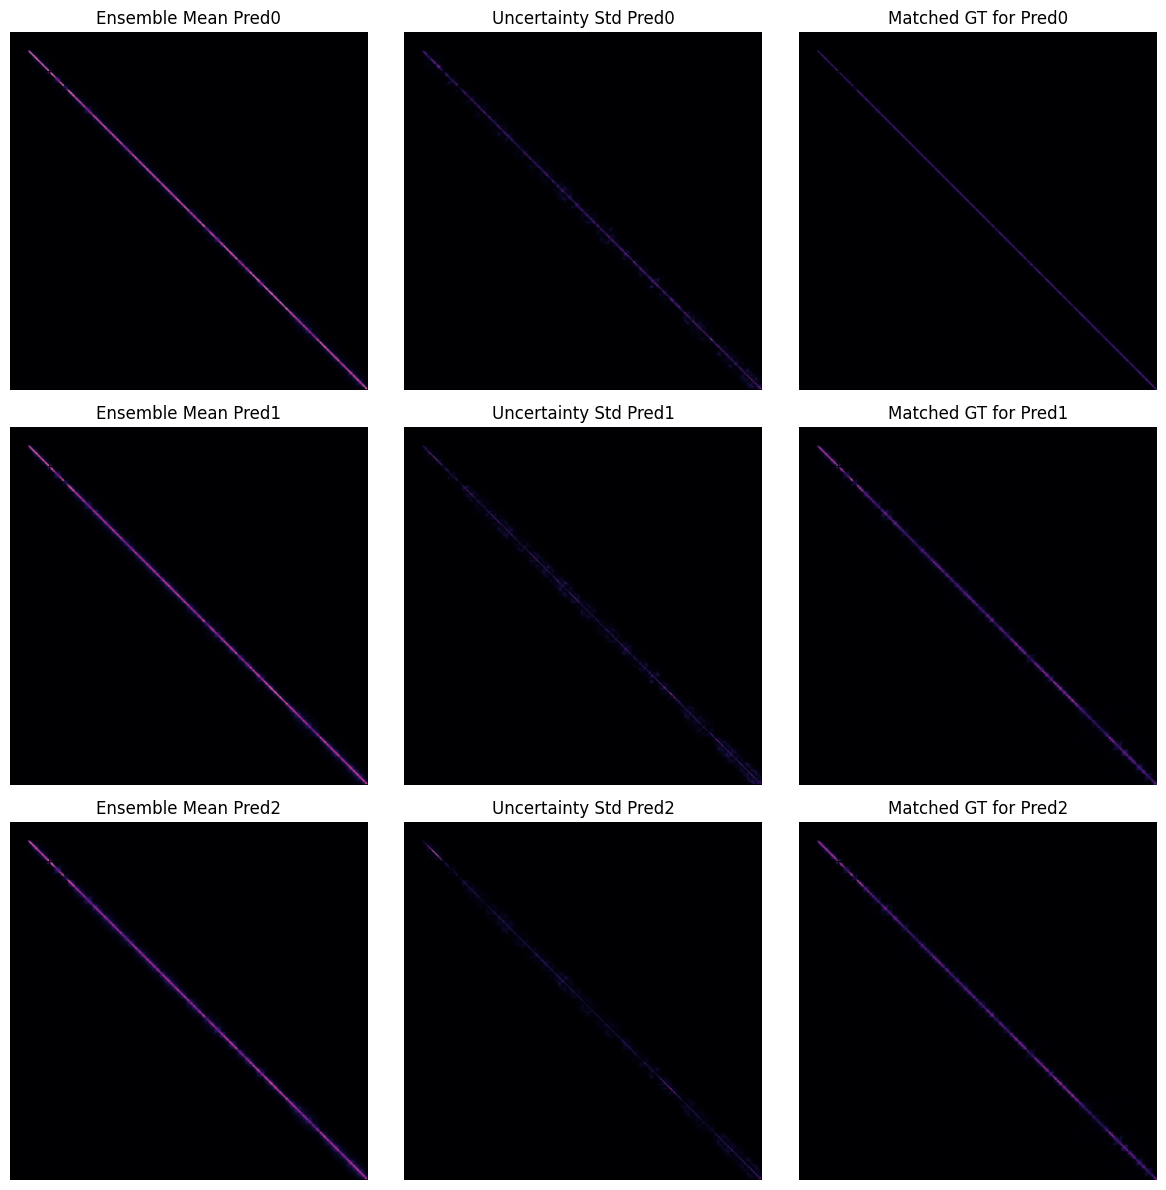

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    axes[i, 0].imshow(ensemble_mean[i], cmap="magma")
    axes[i, 0].set_title(f"Ensemble Mean Pred{i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(ensemble_std[i], cmap="magma")
    axes[i, 1].set_title(f"Uncertainty Std Pred{i}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(matched_gt[i], cmap="magma")
    axes[i, 2].set_title(f"Matched GT for Pred{i}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

# **Patch extractor**

In [6]:
PATCH = 64
STRIDE = 32
MAX_BAND_PATCH_DIST = 2   # keep near-diagonal patches only

def extract_patches_with_positions(mean_maps, std_maps, gt_maps, patch=64, stride=32, max_band_patch_dist=2):
    """
    mean_maps, std_maps, gt_maps: shape (3, H, W)
    Returns:
        X: shape (num_patches, 2, patch, patch)
        Y: shape (num_patches, 1, patch, patch)
        meta: list of (horizon_idx, row, col)
    """
    X_list, Y_list, meta = [], [], []
    num_h, H, W = mean_maps.shape

    for h in range(num_h):
        for r in range(0, H - patch + 1, stride):
            for c in range(0, W - patch + 1, stride):
                # only keep diagonal / near-diagonal regions
                patch_row_idx = r // stride
                patch_col_idx = c // stride
                if abs(patch_row_idx - patch_col_idx) > max_band_patch_dist:
                    continue

                mean_patch = mean_maps[h, r:r+patch, c:c+patch]
                std_patch  = std_maps[h,  r:r+patch, c:c+patch]
                gt_patch   = gt_maps[h,   r:r+patch, c:c+patch]

                x = np.stack([mean_patch, std_patch], axis=0)   # (2, patch, patch)
                y = gt_patch[None, ...]                         # (1, patch, patch)

                X_list.append(x)
                Y_list.append(y)
                meta.append((h, r, c))

    X = np.stack(X_list, axis=0).astype(np.float32)
    Y = np.stack(Y_list, axis=0).astype(np.float32)
    return X, Y, meta

# **Build the patch dataset**

In [7]:
X, Y, meta = extract_patches_with_positions(
    ensemble_mean,
    ensemble_std,
    matched_gt,
    patch=PATCH,
    stride=STRIDE,
    max_band_patch_dist=MAX_BAND_PATCH_DIST
)

print("X shape:", X.shape)   # (N, 2, 64, 64)
print("Y shape:", Y.shape)   # (N, 1, 64, 64)
print("Number of patches:", len(meta))
print("First 5 meta entries:", meta[:5])

X shape: (672, 2, 64, 64)
Y shape: (672, 1, 64, 64)
Number of patches: 672
First 5 meta entries: [(0, 0, 0), (0, 0, 32), (0, 0, 64), (0, 32, 0), (0, 32, 32)]


# **Visualize one training sample**

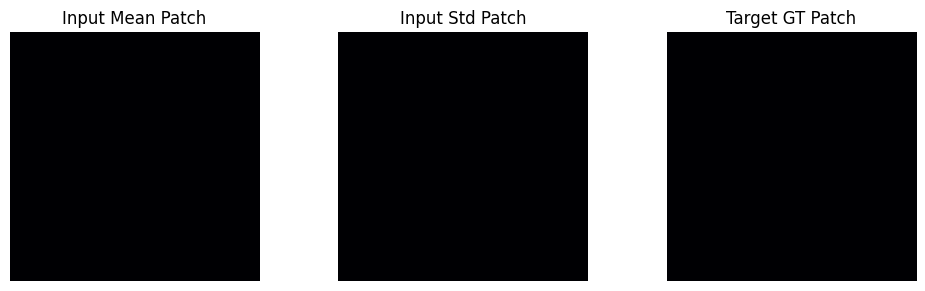

meta: (0, 0, 0)


In [8]:
sample_idx = 0

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(X[sample_idx, 0], cmap="magma")
axes[0].set_title("Input Mean Patch")
axes[0].axis("off")

axes[1].imshow(X[sample_idx, 1], cmap="magma")
axes[1].set_title("Input Std Patch")
axes[1].axis("off")

axes[2].imshow(Y[sample_idx, 0], cmap="magma")
axes[2].set_title("Target GT Patch")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("meta:", meta[sample_idx])

# **Train/val split**

In [9]:
indices = np.arange(len(X))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val     = X[val_idx], Y[val_idx]

print("Train patches:", X_train.shape[0])
print("Val patches  :", X_val.shape[0])

Train patches: 537
Val patches  : 135


# **Save the prepared patch data**

In [11]:
np.save(f"{SAVE_DIR}/X_train.npy", X_train)
np.save(f"{SAVE_DIR}/Y_train.npy", Y_train)
np.save(f"{SAVE_DIR}/X_val.npy", X_val)
np.save(f"{SAVE_DIR}/Y_val.npy", Y_val)

print("Saved prepared patch data to:", SAVE_DIR)

Saved prepared patch data to: /content/drive/MyDrive/HicForecast_Project_experiment_2B


# **Load saved patch data**

In [12]:
X_train = np.load(f"{SAVE_DIR}/X_train.npy")
Y_train = np.load(f"{SAVE_DIR}/Y_train.npy")
X_val   = np.load(f"{SAVE_DIR}/X_val.npy")
Y_val   = np.load(f"{SAVE_DIR}/Y_val.npy")

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val  :", X_val.shape)
print("Y_val  :", Y_val.shape)

X_train: (537, 2, 64, 64)
Y_train: (537, 1, 64, 64)
X_val  : (135, 2, 64, 64)
Y_val  : (135, 1, 64, 64)


# **Build Dataset + DataLoader**

In [14]:
class HiCRefinerDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_ds = HiCRefinerDataset(X_train, Y_train)
val_ds   = HiCRefinerDataset(X_val, Y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 17
Val batches  : 5


# **Define the model**

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.act(self.conv1(x))
        out = self.conv2(out)
        out = self.act(out + identity)
        return out

class UncertaintyGuidedRefiner(nn.Module):
    def __init__(self, in_channels=2, hidden=32, num_blocks=4):
        super().__init__()
        self.head = nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden) for _ in range(num_blocks)])
        self.tail = nn.Conv2d(hidden, 1, kernel_size=3, padding=1)

    def forward(self, x):
        """
        x shape: (B, 2, H, W)
        x[:,0:1] = ensemble mean patch
        x[:,1:2] = uncertainty std patch
        """
        mean_patch = x[:, 0:1]
        feat = F.relu(self.head(x))
        feat = self.blocks(feat)
        residual = self.tail(feat)
        refined = mean_patch + residual
        return refined

# **Initialize model, optimizer, loss**

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UncertaintyGuidedRefiner(in_channels=2, hidden=32, num_blocks=4).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15

Using device: cuda


# Training + validation

In [19]:
best_val_loss = float("inf")
best_state = None

train_history = []
val_history = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_history.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)
            running_val_loss += loss.item() * xb.size(0)

    avg_val_loss = running_val_loss / len(val_loader.dataset)
    val_history.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d} | Train L1: {avg_train_loss:.6f} | Val L1: {avg_val_loss:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = copy.deepcopy(model.state_dict())

print("Best val loss:", best_val_loss)

Epoch 1/15 [Train]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 01 | Train L1: 4.981943 | Val L1: 4.482675


Epoch 2/15 [Train]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 2/15 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 14/15 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 14 | Train L1: 4.510252 | Val L1: 4.278689


Epoch 15/15 [Train]:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 15 | Train L1: 4.498526 | Val L1: 4.165453
Best val loss: 4.165452692243788


# **Save best model**

In [20]:
MODEL_PATH = f"{SAVE_DIR}/uncertainty_guided_refiner_best.pt"
torch.save(best_state, MODEL_PATH)
print("Saved best model to:", MODEL_PATH)

Saved best model to: /content/drive/MyDrive/HicForecast_Project_experiment_2B/uncertainty_guided_refiner_best.pt


# **Plot training curve**

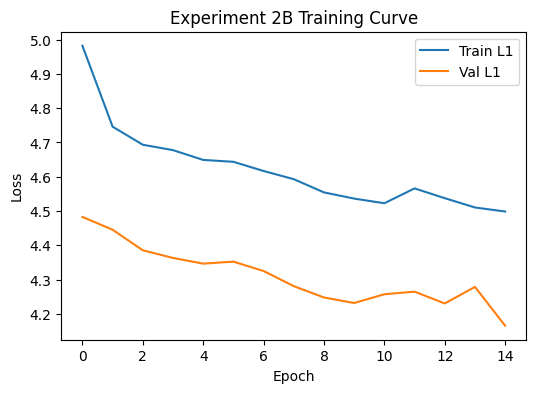

In [21]:
plt.figure(figsize=(6,4))
plt.plot(train_history, label="Train L1")
plt.plot(val_history, label="Val L1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2B Training Curve")
plt.legend()
plt.show()

# **Rebuild full patch set and reconstruct refined full maps**

Since we need full-map reconstruction, we need to regenerate:
*   full X
*   meta
from the original full matrices.

# **Reload full inputs and regenerate all patches**

In [22]:
ROOT = "/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main" #copied from experiment 1B for ensemble

MEAN_PATH = f"{ROOT}/ensemble_outputs/pred_ensemble_mean.npy"
STD_PATH  = f"{ROOT}/ensemble_outputs/pred_ensemble_std.npy"
GT_PATH   = f"{ROOT}/example_data/processed/data_gt_chr19_64.npy"

ensemble_mean = np.load(MEAN_PATH)
ensemble_std  = np.load(STD_PATH)
gt = np.load(GT_PATH)

gt_match = [2, 5, 5]
matched_gt = np.stack([gt[gt_match[0]], gt[gt_match[1]], gt[gt_match[2]]], axis=0)

PATCH = 64
STRIDE = 32
MAX_BAND_PATCH_DIST = 2

# **Regenerate full patch set + meta**

In [23]:
def extract_patches_with_positions(mean_maps, std_maps, gt_maps, patch=64, stride=32, max_band_patch_dist=2):
    X_list, Y_list, meta = [], [], []
    num_h, H, W = mean_maps.shape

    for h in range(num_h):
        for r in range(0, H - patch + 1, stride):
            for c in range(0, W - patch + 1, stride):
                patch_row_idx = r // stride
                patch_col_idx = c // stride
                if abs(patch_row_idx - patch_col_idx) > max_band_patch_dist:
                    continue

                mean_patch = mean_maps[h, r:r+patch, c:c+patch]
                std_patch  = std_maps[h,  r:r+patch, c:c+patch]
                gt_patch   = gt_maps[h,   r:r+patch, c:c+patch]

                x = np.stack([mean_patch, std_patch], axis=0)
                y = gt_patch[None, ...]

                X_list.append(x)
                Y_list.append(y)
                meta.append((h, r, c))

    X = np.stack(X_list, axis=0).astype(np.float32)
    Y = np.stack(Y_list, axis=0).astype(np.float32)
    return X, Y, meta

X_all, Y_all, meta_all = extract_patches_with_positions(
    ensemble_mean,
    ensemble_std,
    matched_gt,
    patch=PATCH,
    stride=STRIDE,
    max_band_patch_dist=MAX_BAND_PATCH_DIST
)

print("X_all:", X_all.shape)
print("Y_all:", Y_all.shape)
print("meta count:", len(meta_all))

X_all: (672, 2, 64, 64)
Y_all: (672, 1, 64, 64)
meta count: 672


# **Run the trained model on all patches**

In [24]:
best_model = UncertaintyGuidedRefiner(in_channels=2, hidden=32, num_blocks=4).to(device)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
best_model.eval()

X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
all_loader = DataLoader(X_all_tensor, batch_size=64, shuffle=False)

refined_patches = []

with torch.no_grad():
    for xb in all_loader:
        xb = xb.to(device)
        pred = best_model(xb)
        refined_patches.append(pred.cpu().numpy())

refined_patches = np.concatenate(refined_patches, axis=0)  # (N,1,64,64)
print("refined_patches shape:", refined_patches.shape)

refined_patches shape: (672, 1, 64, 64)


# **Reconstruct full refined maps from overlapping patches**

In [25]:
def reconstruct_from_patches(refined_patches, meta, out_shape, patch=64):
    """
    refined_patches: (N,1,patch,patch)
    meta: list of (horizon, row, col)
    out_shape: (3, H, W)
    """
    num_h, H, W = out_shape
    canvas = np.zeros((num_h, H, W), dtype=np.float32)
    weight = np.zeros((num_h, H, W), dtype=np.float32)

    for i, (h, r, c) in enumerate(meta):
        patch_pred = refined_patches[i, 0]
        canvas[h, r:r+patch, c:c+patch] += patch_pred
        weight[h, r:r+patch, c:c+patch] += 1.0

    weight[weight == 0] = 1.0
    return canvas / weight

refined_full = reconstruct_from_patches(
    refined_patches,
    meta_all,
    out_shape=ensemble_mean.shape,
    patch=PATCH
)

print("refined_full shape:", refined_full.shape)
np.save(f"{SAVE_DIR}/pred_refined_2B.npy", refined_full)
print("Saved full refined prediction.")

refined_full shape: (3, 1534, 1534)
Saved full refined prediction.


# **Evaluate against baseline / ensemble mean / graph diffusion**

In [27]:
def compute_pcc(a, b):
    a = a.astype(np.float64).ravel()
    b = b.astype(np.float64).ravel()
    return np.corrcoef(a, b)[0, 1]

def compute_ssim(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    data_range = max(a.max(), b.max()) - min(a.min(), b.min())
    if data_range == 0:
        data_range = 1.0
    return ssim(a, b, data_range=data_range)

def compute_psnr(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    data_range = max(a.max(), b.max()) - min(a.min(), b.min())
    if data_range == 0:
        data_range = 1.0
    return psnr(a, b, data_range=data_range)

def compute_mae(a, b):
    return mean_absolute_error(a.ravel(), b.ravel())

def compute_mse(a, b):
    return mean_squared_error(a.ravel(), b.ravel())

def evaluate_prediction(pred_maps, gt_maps, gt_match):
    rows = []
    for pred_idx, gt_idx in enumerate(gt_match):
        pred_map = pred_maps[pred_idx]
        gt_map = gt_maps[gt_idx]

        rows.append({
            "Pred idx": pred_idx,
            "GT idx": gt_idx,
            "PCC": compute_pcc(gt_map, pred_map),
            "SSIM": compute_ssim(gt_map, pred_map),
            "PSNR": compute_psnr(gt_map, pred_map),
            "MAE": compute_mae(gt_map, pred_map),
            "MSE": compute_mse(gt_map, pred_map),
        })
    return pd.DataFrame(rows)

# **Evaluate refined result**

In [28]:
refined_df = evaluate_prediction(refined_full, gt, gt_match)
refined_df.round(4)

,Pred idx,GT idx,PCC,SSIM,PSNR,MAE,MSE
0,0,2,0.9747,0.9906,48.7888,0.7848,9.5604
1,1,5,0.9380,0.9661,40.8251,1.0813,17.1346
2,2,5,0.9451,0.9663,41.1852,1.0574,15.7177


# **Load ensemble mean metrics too, (important)**

In [29]:
ensemble_df = evaluate_prediction(ensemble_mean, gt, gt_match)
ensemble_df.round(4)

,Pred idx,GT idx,PCC,SSIM,PSNR,MAE,MSE
0,0,2,0.9776,0.9885,48.7437,0.8537,9.4679
1,1,5,0.9442,0.9612,41.0255,1.0839,16.0620
2,2,5,0.9444,0.9608,40.5319,1.0981,17.9953


# **Add baseline and graph diffusion reference**

In [30]:
baseline_df = pd.DataFrame([
    {"Pred idx": 0, "GT idx": 2, "PCC": 0.9695, "SSIM": 0.9877, "PSNR": 47.56, "MAE": 0.9199, "MSE": 12.44},
    {"Pred idx": 1, "GT idx": 5, "PCC": 0.9422, "SSIM": 0.9609, "PSNR": 40.44, "MAE": 1.1051, "MSE": 18.39},
    {"Pred idx": 2, "GT idx": 5, "PCC": 0.9431, "SSIM": 0.9604, "PSNR": 40.76, "MAE": 1.1048, "MSE": 17.08},
])

graph_df = pd.DataFrame([
    {"Pred idx": 0, "GT idx": 2, "PCC": 0.8937, "SSIM": 0.9818, "PSNR": 42.07, "MAE": 1.2767, "MSE": 43.97},
    {"Pred idx": 1, "GT idx": 5, "PCC": 0.8974, "SSIM": 0.9575, "PSNR": 37.82, "MAE": 1.2478, "MSE": 33.64},
    {"Pred idx": 2, "GT idx": 5, "PCC": 0.8897, "SSIM": 0.9562, "PSNR": 37.88, "MAE": 1.2824, "MSE": 33.11},
])

print("Baseline avg:\n", baseline_df.mean(numeric_only=True))
print("\nEnsemble avg:\n", ensemble_df.mean(numeric_only=True))
print("\nGraph diffusion avg:\n", graph_df.mean(numeric_only=True))
print("\nRefined 2B avg:\n", refined_df.mean(numeric_only=True))

Baseline avg:
 Pred idx     1.000000
GT idx       4.000000
PCC          0.951600
SSIM         0.969667
PSNR        42.920000
MAE          1.043267
MSE         15.970000
dtype: float64

Ensemble avg:
 Pred idx     1.000000
GT idx       4.000000
PCC          0.955390
SSIM         0.970156
PSNR        43.433730
MAE          1.011911
MSE         14.508393
dtype: float64

Graph diffusion avg:
 Pred idx     1.000000
GT idx       4.000000
PCC          0.893600
SSIM         0.965167
PSNR        39.256667
MAE          1.268967
MSE         36.906667
dtype: float64

Refined 2B avg:
 Pred idx     1.000000
GT idx       4.000000
PCC          0.952587
SSIM         0.974300
PSNR        43.599724
MAE          0.974522
MSE         14.137556
dtype: float64


# **Final compact comparison table**

In [31]:
summary_df = pd.DataFrame({
    "Method": ["Baseline", "Ensemble Mean", "Graph Diffusion", "Experiment 2B Refiner"],
    "PCC": [
        baseline_df["PCC"].mean(),
        ensemble_df["PCC"].mean(),
        graph_df["PCC"].mean(),
        refined_df["PCC"].mean(),
    ],
    "SSIM": [
        baseline_df["SSIM"].mean(),
        ensemble_df["SSIM"].mean(),
        graph_df["SSIM"].mean(),
        refined_df["SSIM"].mean(),
    ],
    "PSNR": [
        baseline_df["PSNR"].mean(),
        ensemble_df["PSNR"].mean(),
        graph_df["PSNR"].mean(),
        refined_df["PSNR"].mean(),
    ],
    "MAE": [
        baseline_df["MAE"].mean(),
        ensemble_df["MAE"].mean(),
        graph_df["MAE"].mean(),
        refined_df["MAE"].mean(),
    ],
    "MSE": [
        baseline_df["MSE"].mean(),
        ensemble_df["MSE"].mean(),
        graph_df["MSE"].mean(),
        refined_df["MSE"].mean(),
    ],
})

summary_df.round(4)

,Method,PCC,SSIM,PSNR,MAE,MSE
0,Baseline,0.9516,0.9697,42.9200,1.0433,15.9700
1,Ensemble Mean,0.9554,0.9702,43.4337,1.0119,14.5084
2,Graph Diffusion,0.8936,0.9652,39.2567,1.2690,36.9067
3,Experiment 2B Refiner,0.9526,0.9743,43.5997,0.9745,14.1376


# **Save results**

In [32]:
refined_df.to_csv(f"{SAVE_DIR}/experiment_2B_refined_metrics.csv", index=False)
summary_df.to_csv(f"{SAVE_DIR}/experiment_2B_summary_compare.csv", index=False)

print("Saved:")
print(f"{SAVE_DIR}/experiment_2B_refined_metrics.csv")
print(f"{SAVE_DIR}/experiment_2B_summary_compare.csv")

Saved:
/content/drive/MyDrive/HicForecast_Project_experiment_2B/experiment_2B_refined_metrics.csv
/content/drive/MyDrive/HicForecast_Project_experiment_2B/experiment_2B_summary_compare.csv


# **Visual comparison**

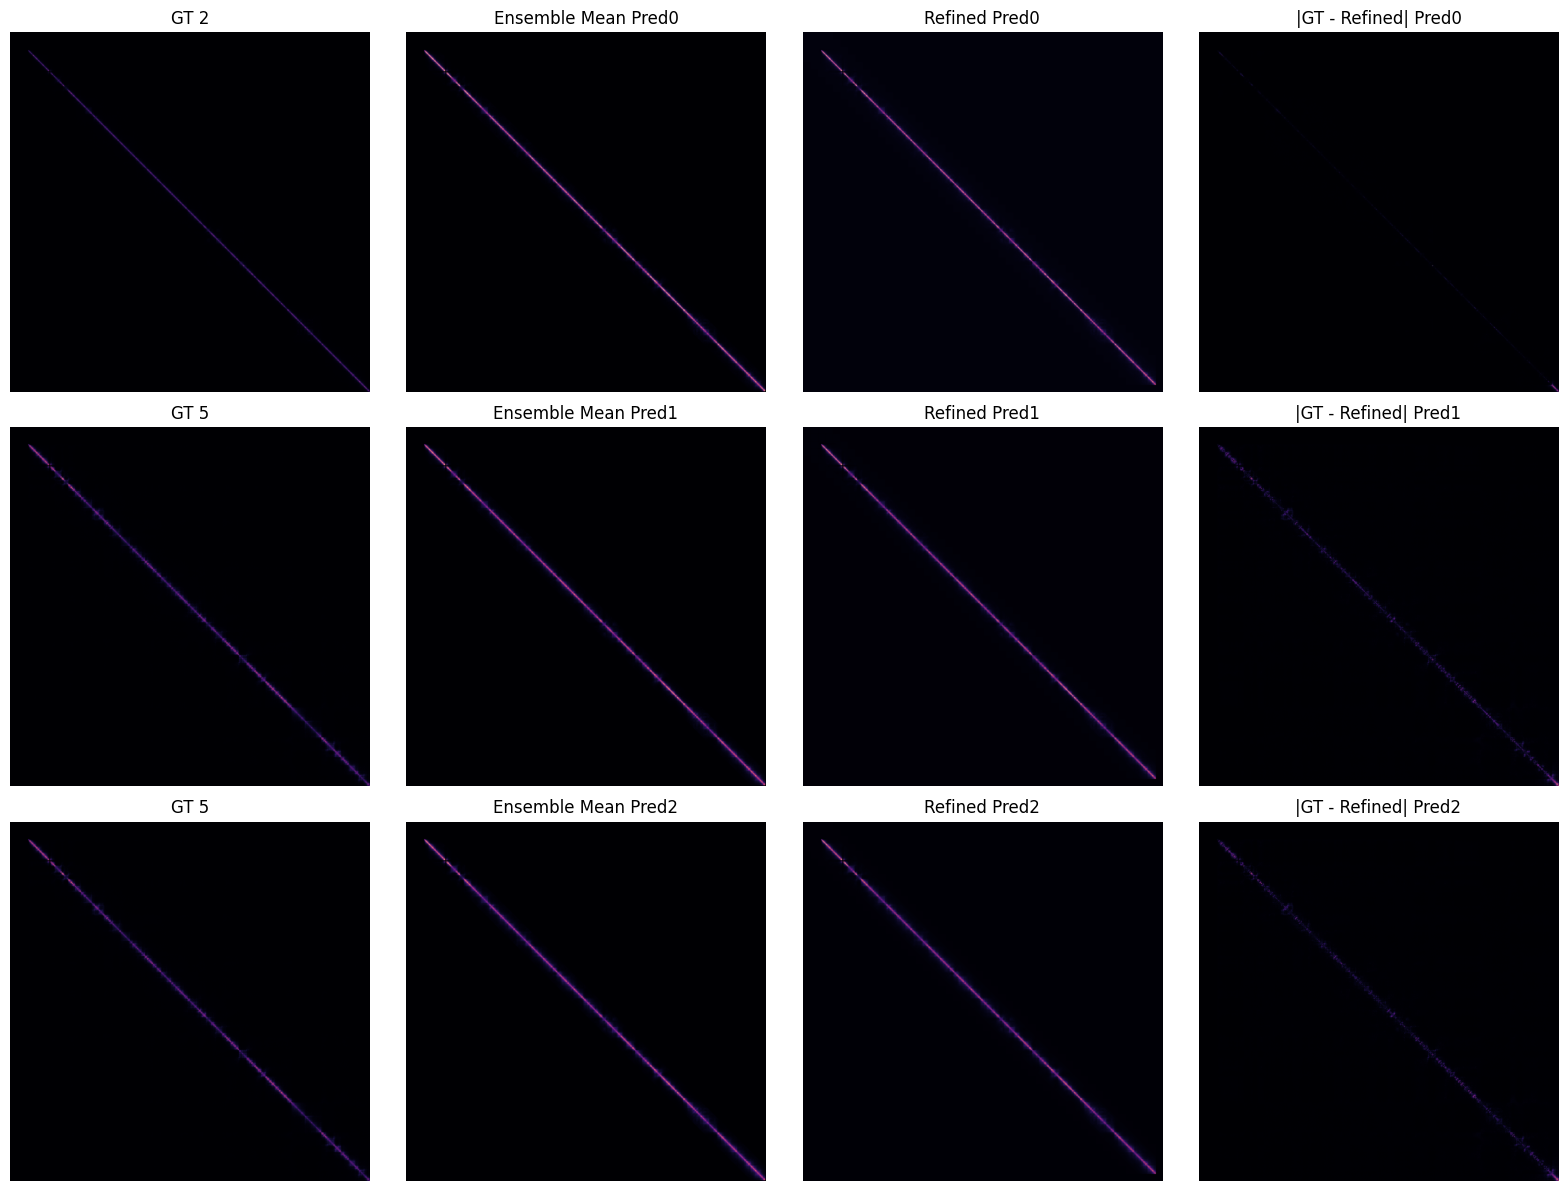

In [33]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, gt_idx in enumerate(gt_match):
    g = gt[gt_idx]
    m = ensemble_mean[i]
    r = refined_full[i]
    e = np.abs(g - r)

    axes[i, 0].imshow(g, cmap="magma")
    axes[i, 0].set_title(f"GT {gt_idx}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(m, cmap="magma")
    axes[i, 1].set_title(f"Ensemble Mean Pred{i}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(r, cmap="magma")
    axes[i, 2].set_title(f"Refined Pred{i}")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(e, cmap="magma")
    axes[i, 3].set_title(f"|GT - Refined| Pred{i}")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()